In [ ]:
import sys
sys.path.append('../../')
import os.path as osp

import qdre
import Camel.equations as equations

import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda:0


## Initiate the datasets

In [2]:
DATA_DIR = "./data"
SAVE_DIR = "./models"

In [ ]:
training_settings = {}

LOSS = "qdre"

source_mixture_coef = (4, -1)
source_scales = (2.5, 2.3)
target_mixture_coef = (2, -1)
target_scales = (2, 1.2)

source_file = osp.join(DATA_DIR, "base_distribution_mc_data")
target_file = osp.join(DATA_DIR, "target_distribution_mc_data")


train_base_dataset = qdre.preprocessing.Dataset(source_file + "_train.npy", 0)
valid_base_dataset = qdre.preprocessing.Dataset(source_file + "_val.npy", 0)

train_target_dataset = qdre.preprocessing.Dataset(target_file + "_train.npy", 1)
valid_target_dataset = qdre.preprocessing.Dataset(target_file + "_val.npy", 1)

training_settings.update({
    "source_file": source_file,
    "target_file": target_file,
    "source_mixture_coef": source_mixture_coef,
    "source_scales": source_scales,
    "target_mixture_coef": target_mixture_coef,
    "target_scales": target_scales,
    "loss": LOSS,
})

## Load the data

In [4]:
source_weight_norm = train_base_dataset.process(normalize_weights=True)
print(source_weight_norm)
source_valid_weight_norm = valid_base_dataset.process(normalize_weights=True)

target_weight_norm = train_target_dataset.process(normalize_weights=True)
print(target_weight_norm)
valid_target_dataset.process(normalize_weights=True)

#weight_scale = source_valid_weight_norm / source_weight_norm
#weight_scale

tensor(0.6008)
tensor(0.3344)


tensor(0.3339)

In [5]:
train_generator_data = qdre.preprocessing.CombinedDataset(train_base_dataset, train_target_dataset)
valid_generator_data = qdre.preprocessing.CombinedDataset(valid_base_dataset, valid_target_dataset)

## Do some data preprocessing for standardized inputs and weights

In [6]:
X_scaler, train_weight_norm = qdre.preprocessing.get_scaling(train_generator_data)
_, valid_weight_norm = qdre.preprocessing.get_scaling(valid_generator_data)
print(train_weight_norm, valid_weight_norm)

100%|██████████| 1172/1172 [00:06<00:00, 180.95it/s]

tensor(1.0000) tensor(1.0000)


## Prepare the data for training

In [7]:
random_seed = 0

torch.manual_seed(random_seed)
batch_size = int(2**8)
training_settings.update({
    "batch_size": batch_size,
    "random_seed": random_seed
})

train_loader = DataLoader(train_generator_data, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_generator_data, batch_size=batch_size, shuffle=False)

## Construct the model

In [8]:
inputs = 2
hidden_nodes = [64, 64, 64]
outputs = 1

if LOSS == "bce" or LOSS == "qdre":
    model = qdre.models.Classifier(inputs, hidden_nodes, outputs)
else:
    model = qdre.models.Classifier(inputs, hidden_nodes, outputs, final_activation="linear")
print(model)
print("----------")

model = model.to(DEVICE)

learning_rate = 3e-5
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Get the analytical optimal classifier
s_optimal = equations.optimal_binary_classifier(source_mixture_coef, source_scales, target_mixture_coef, target_scales)

training_settings.update({
    "learning_rate": learning_rate,
    "optimizer": "Adam"
})

model_name = "classifier_{}_batch{}".format(LOSS, batch_size)
model_name

Classifier(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
----------


'classifier_qdre_batch256'

## Perform the training

In [ ]:
n_epochs = 1500
stale_epochs = 0
best_valid_loss = 99999
patience = 20
max_num_batches = int(int(1e5) / batch_size)
t = tqdm(range(0, n_epochs))

training_losses = [qdre.train.test(
        model,
        train_loader,
        X_scaler=X_scaler,
        loss=LOSS,
        weight_norm=train_weight_norm,
        max_num_batches=max_num_batches,
        device=DEVICE,
        progress_bar=False,
        leave=False
    )[1],]
validation_losses = [qdre.train.test(
        model,
        valid_loader,
        X_scaler=X_scaler,
        loss=LOSS,
        weight_norm=valid_weight_norm,
        device=DEVICE,
        progress_bar=False,
        leave=False
    )[1],]

optimal_train_loss = np.nan
optimal_valid_loss = np.nan
    
training_settings.update({
    "optimal_train_loss": optimal_train_loss,
    "optimal_valid_loss": optimal_valid_loss
})


for epoch in t:
    loss = qdre.train.train(
        model,
        optimizer,
        train_loader,
        X_scaler=X_scaler,
        loss=LOSS,
        weight_norm=train_weight_norm,
        max_num_batches=max_num_batches,
        device=DEVICE,
        leave=bool(epoch == n_epochs - 1),
        progress_bar=False,
    )
    #loss -= optimal_train_loss
    training_losses.append(loss[1])

    valid_loss = qdre.train.test(
        model,
        valid_loader,
        X_scaler=X_scaler,
        loss=LOSS,
        weight_norm=valid_weight_norm,
        device=DEVICE,
        leave=bool(epoch == n_epochs - 1),
        progress_bar=False,
    )
    #valid_loss -= optimal_valid_loss
    validation_losses.append(valid_loss[1])
    print("Epoch: {:02d}, Training Loss:   {:.4f}".format(epoch, loss[1]))
    print("           Validation Loss: {:.4f}".format(valid_loss[1]))

    if valid_loss[1] < best_valid_loss:
        best_valid_loss = valid_loss[1]
        training_settings.update({
            "n_epochs": epoch+1,
            "training_losses": training_losses,
            "validation_losses": validation_losses
        })
        model_metadata = qdre.train.get_model_metadata(training_settings, model, X_scaler, train_weight_norm)
        qdre.train.save_model_data(model, model_metadata, savedir=SAVE_DIR,name=model_name, save_onnx=False, device=DEVICE)
        print("New best model saved to: {}.zip".format(osp.join(SAVE_DIR, model_name)))
        #torch.save(model.state_dict(), modpath)
        stale_epochs = 0
    else:
        print("Stale epoch")
        stale_epochs += 1
    if stale_epochs >= patience:
        print("Early stopping after %i stale epochs" % patience)
        break

  0%|          | 0/1500 [00:00<?, ?it/s]

Epoch: 00, Training Loss:   0.9441
           Validation Loss: 0.9377
New best model saved to: models/classifier4_qdre_batch256.zip
Epoch: 01, Training Loss:   0.9277
           Validation Loss: 0.9242
New best model saved to: models/classifier4_qdre_batch256.zip
Epoch: 02, Training Loss:   0.9136
           Validation Loss: 0.9163
New best model saved to: models/classifier4_qdre_batch256.zip
Epoch: 03, Training Loss:   0.9023
           Validation Loss: 0.9132
New best model saved to: models/classifier4_qdre_batch256.zip
Epoch: 04, Training Loss:   0.9087
           Validation Loss: 0.9123
New best model saved to: models/classifier4_qdre_batch256.zip
Epoch: 05, Training Loss:   0.9178
           Validation Loss: 0.9119
New best model saved to: models/classifier4_qdre_batch256.zip
Epoch: 06, Training Loss:   0.9051
           Validation Loss: 0.9115
New best model saved to: models/classifier4_qdre_batch256.zip
Epoch: 07, Training Loss:   0.9003
           Validation Loss: 0.9112
New be

### Look at loss curves

Text(0, 0.5, 'QDRE Loss')

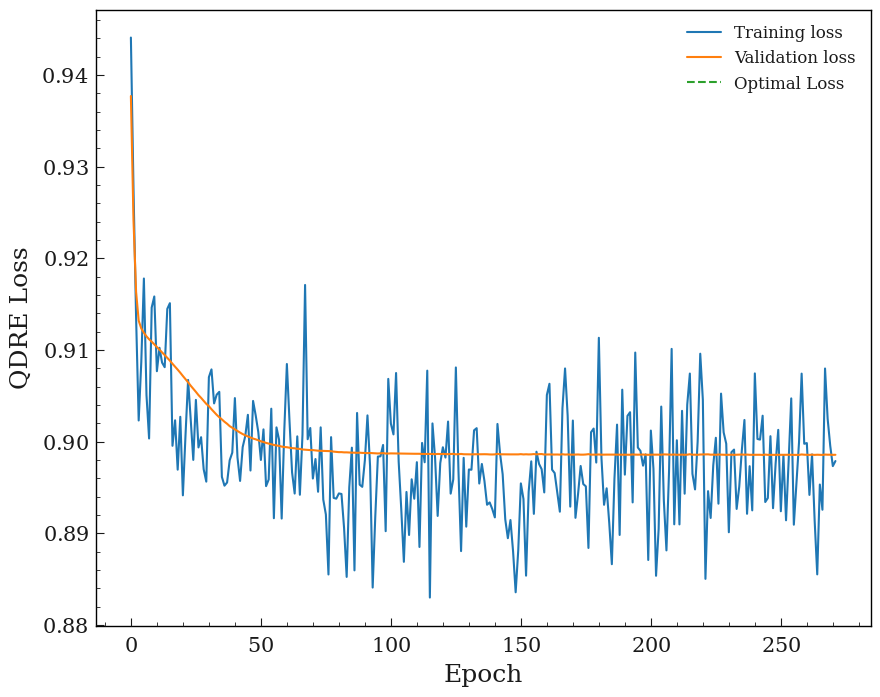

In [9]:
fig,ax = plt.subplots()
fig.set_size_inches(10, 8)

starting_epoch = 1
training_loss_per_epoch = np.array(training_losses[starting_epoch:])#.mean(axis=1)
#training_std_per_epoch = np.array(training_losses[starting_epoch:]).std(axis=1)

validation_loss_per_epoch = np.array(validation_losses[starting_epoch:])#.mean(axis=1)
#validation_std_per_epoch = np.array(validation_losses[starting_epoch:]).std(axis=1)

#training_lower_bar = training_loss_per_epoch - training_std_per_epoch
#training_upper_bar = training_loss_per_epoch + training_std_per_epoch

#validation_lower_bar = validation_loss_per_epoch - validation_std_per_epoch
#validation_upper_bar = validation_loss_per_epoch + validation_std_per_epoch


t1 = np.arange(len(training_loss_per_epoch))
t2 = np.arange(len(validation_loss_per_epoch))
ax.plot(t1, training_loss_per_epoch, '-', label="Training loss", c='tab:blue')
#ax.fill_between(t1, training_lower_bar, training_upper_bar, color='tab:blue', alpha=0.30)

ax.plot(t2, validation_loss_per_epoch, '-', label="Validation loss", c='tab:orange')
#ax.fill_between(t2, validation_lower_bar, validation_upper_bar, color='tab:orange', alpha=0.30)

ax.plot([0, max([t1.max(), t2.max()])], [training_settings["optimal_valid_loss"]]*2, '--', color='tab:green', label="Optimal Loss")

#ax.set_xscale('log')
ax.legend()
ax.set_xlabel("Epoch")
ax.set_ylabel("{} Loss".format(LOSS.upper()))